In [80]:
# Import required libraries
import os
import sys
from pyspark.sql import SparkSession
from pyspark.sql.functions import current_timestamp, col, when, lit,round,count
from pyspark.sql.types import (
    StructType,
    StructField,
    StringType,
    IntegerType,
    DoubleType,
    TimestampType,
)

print("✅ Imports successful!")
print(f"Python version: {sys.version}")

# Set environment variables for better output
os.environ["PYSPARK_SUBMIT_ARGS"] = "--jars /opt/spark/jars-custom/*.jar pyspark-shell"

✅ Imports successful!
Python version: 3.11.6 | packaged by conda-forge | (main, Oct  3 2023, 10:40:35) [GCC 12.3.0]


In [81]:
spark = (
    SparkSession.builder.appName("M2-Project")
    # .master("spark://localhost:7077")    
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
    .config("spark.hadoop.fs.s3a.access.key", "admin")
    .config("spark.hadoop.fs.s3a.secret.key", "password")
    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config(
        "spark.hadoop.fs.s3a.aws.credentials.provider",
        "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider",
    )
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate()
)

In [82]:
matches = spark.read.option("inferSchema", "true").option("header","true").csv("s3a://stage/RealEstate.csv")
matches.show(5)

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
|  1|           2012.917|        32.0|                              84.87882|                             10|   24.98298|   121.54024|                      37.9|
|  2|           2012.917|        19.5|                              306.5947|                              9|   24.98034|   121.53951|                      42.2|
|  3|           2013.583|        13.3|                              561.9845|                              5|   24.98746|   121.54391|                      47.3|
|  4|             2013.5|   

In [87]:
matches = (
    matches.withColumn("X1 transaction date", col("X1 transaction date").cast(DoubleType()))
    .withColumn("txn_year", col("X1 transaction date").cast(IntegerType()))
    .withColumn("txn_month" , round( (col("X1 transaction date") - col("txn_year")) * 12,0).cast(IntegerType())) 
)
matches.show(5)

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+--------+---------+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|txn_year|txn_month|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+--------+---------+
|  1|           2012.917|        32.0|                              84.87882|                             10|   24.98298|   121.54024|                      37.9|    2012|       11|
|  2|           2012.917|        19.5|                              306.5947|                              9|   24.98034|   121.53951|                      42.2|    2012|       11|
|  3|           2013.583|        13.3|                              561.9845|                  

In [8]:
# no of records per month 
matches.groupby("txn_year","txn_month").agg(count("*")).show(5)

+--------+---------+--------+
|txn_year|txn_month|count(1)|
+--------+---------+--------+
|    2012|       10|      31|
|    2012|        8|      30|
|    2013|        2|      25|
|    2013|        0|      28|
|    2013|        3|      32|
+--------+---------+--------+
only showing top 5 rows



In [9]:
# how much is the increase in the average house price in 2012 to 2013
# Hint: Apply filter on the transaction date and aggregate the house price using mean
import pyspark.sql.functions as F
(matches.filter(col("txn_year").isin(2012, 2013))
.select("txn_year","Y house price of unit area").groupby("txn_year")
.agg((F.round(F.avg("Y house price of unit area"),2)).alias("avg_price"))
.show(5))

+--------+---------+
|txn_year|avg_price|
+--------+---------+
|    2013|    38.71|
|    2012|     36.3|
+--------+---------+



In [10]:
# Find the count of houses with no convenience store and show the top 10 records
matches.filter(F.col("X4 number of convenience stores")<=0).show(10,False)
matches.filter(F.col("X4 number of convenience stores")<=0).count()

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+--------+---------+
|No |X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|txn_year|txn_month|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+--------+---------+
|31 |2013.5             |25.9        |4519.69                               |0                              |24.94826   |121.49587   |22.1                      |2013    |6        |
|36 |2013.5             |13.9        |4079.418                              |0                              |25.01459   |121.51816   |27.3                      |2013    |6        |
|41 |2013.0             |13.6        |4082.015                              |0                 

67

In [15]:
# Compare the maximum price of houses with convenient store and without convenience store
with_conv = matches.filter(F.col("X4 number of convenience stores")>0).agg(F.max("Y house price of unit area"))
without_conv = matches.filter(F.col("X4 number of convenience stores")<=0).agg(F.max("Y house price of unit area"))
with_conv.toPandas()
without_conv.toPandas()

,max(Y house price of unit area)
0,55.3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int32  
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X5 latitude                             414 non-null    float64
 4   X6 longitude                            414 non-null    float64
 5   txn_year                                414 non-null    int32  
 6   txn_month                               414 non-null    int32  
dtypes: float64(4), int32(3)
memory usage: 17.9 KB


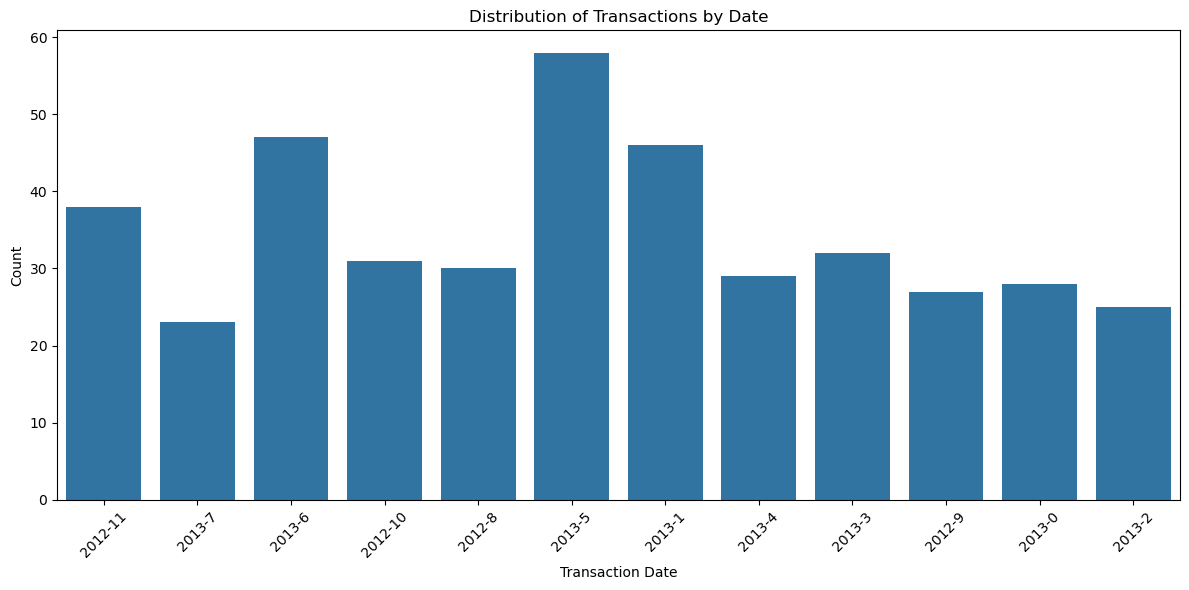

In [39]:
# matches.printSchema()
houses_sdf =  matches.select("No","X2 house age","X3 distance to the nearest MRT station", "X5 latitude", "X6 longitude" , "txn_year", "txn_month")
houses = houses_sdf.toPandas()
houses.info()
houses
from matplotlib import pyplot as plt
import seaborn as sns
houses_txn_date_df =  houses_sdf.withColumn("txn_date", F.concat(col("txn_year"),lit("-"), col("txn_month")) ).select("txn_date").toPandas()
plt.figure(figsize=(12, 6))
sns.countplot(data=houses_txn_date_df, x='txn_date')
plt.xticks(rotation=45)
plt.title('Distribution of Transactions by Date')
plt.xlabel('Transaction Date')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

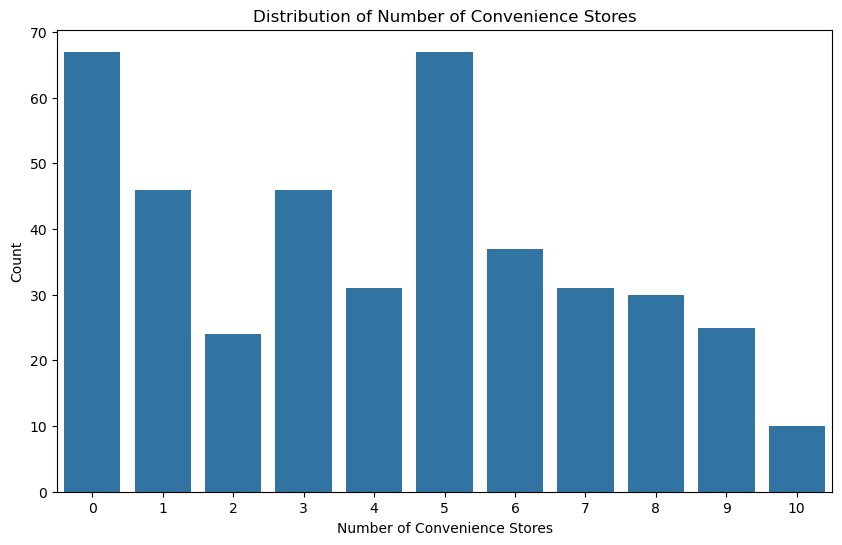

In [46]:
convenience_stores_df = matches.select("X4 number of convenience stores").toPandas()
plt.figure(figsize=(10, 6))
sns.countplot(data=convenience_stores_df, x='X4 number of convenience stores')
plt.title('Distribution of Number of Convenience Stores')
plt.xlabel('Number of Convenience Stores')
plt.ylabel('Count')
plt.show()

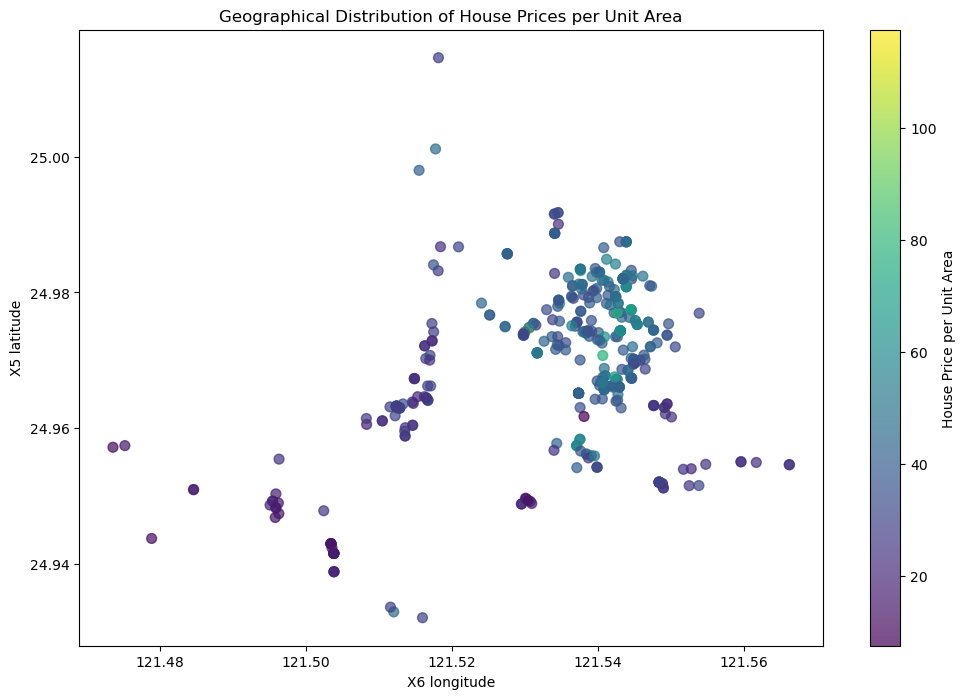

In [53]:
house_geo_df = matches.select("X5 latitude","X6 longitude","Y house price of unit area").toPandas()

# Create scatter plot for geographical distribution
plt.figure(figsize=(12, 8))
plt.scatter(house_geo_df['X6 longitude'], 
       house_geo_df['X5 latitude'], 
       c=house_geo_df['Y house price of unit area'], 
       s=50, 
       cmap='viridis', 
       alpha=0.7)
plt.colorbar(label='House Price per Unit Area')
plt.xlabel('X6 longitude')
plt.ylabel('X5 latitude')
plt.title('Geographical Distribution of House Prices per Unit Area')
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 10 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int32  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int32  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
 8   txn_year                                414 non-null    int32  
 9   txn_month                               414 non-null    int32  
dtypes: float64(6), int32(4)
memory usage: 26.0 KB


<Figure size 1500x1200 with 0 Axes>

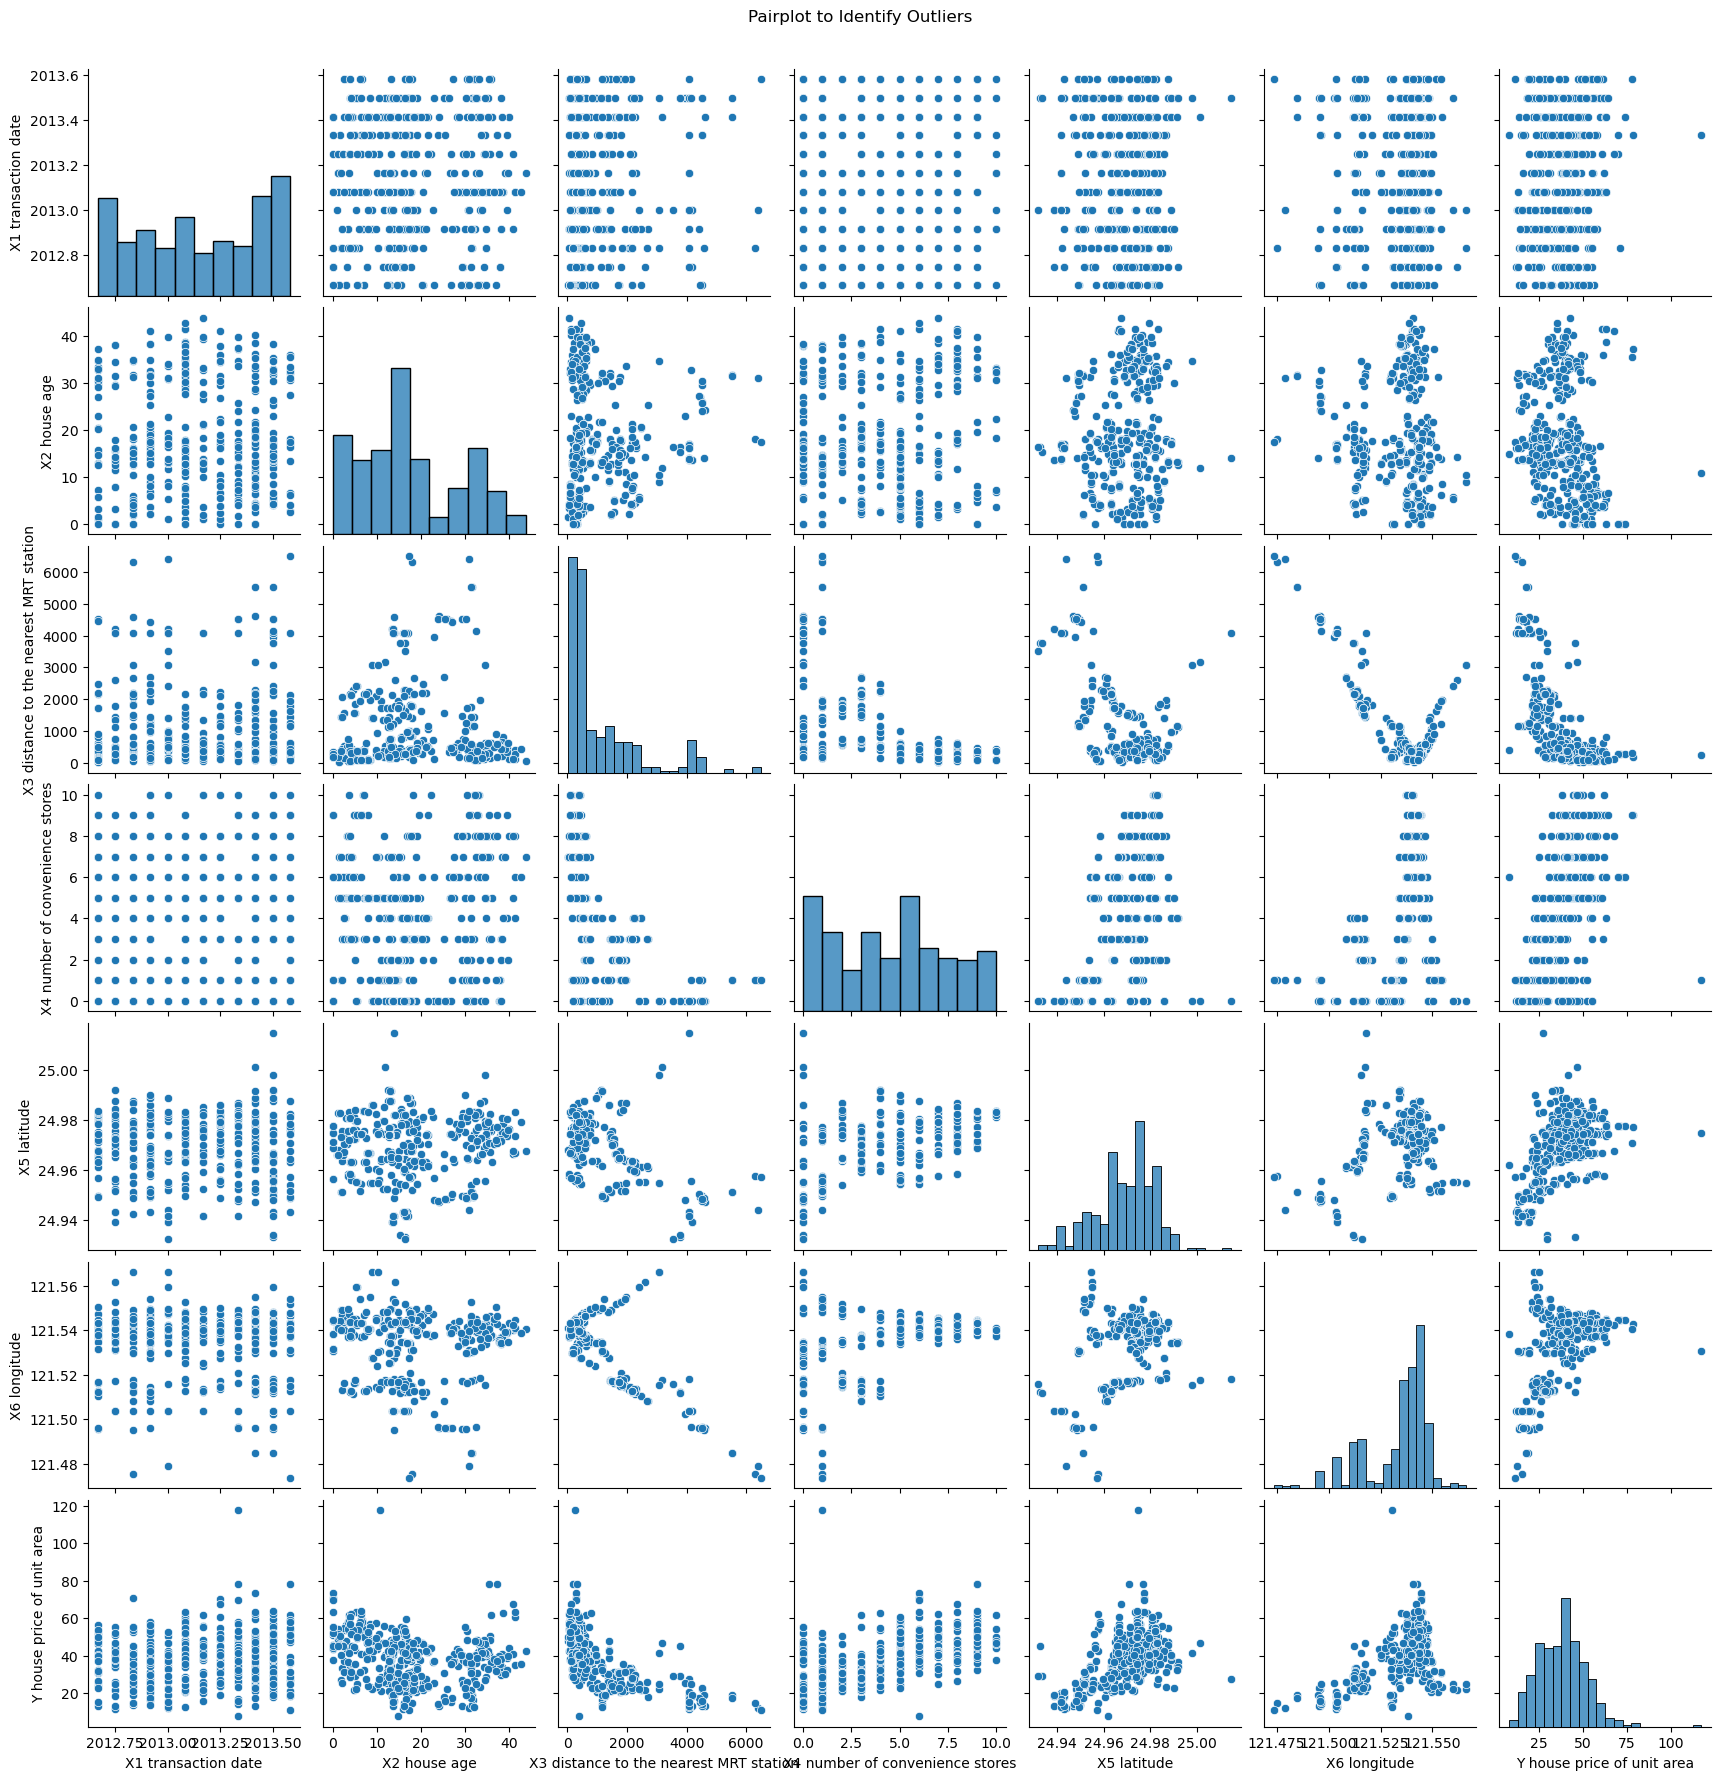

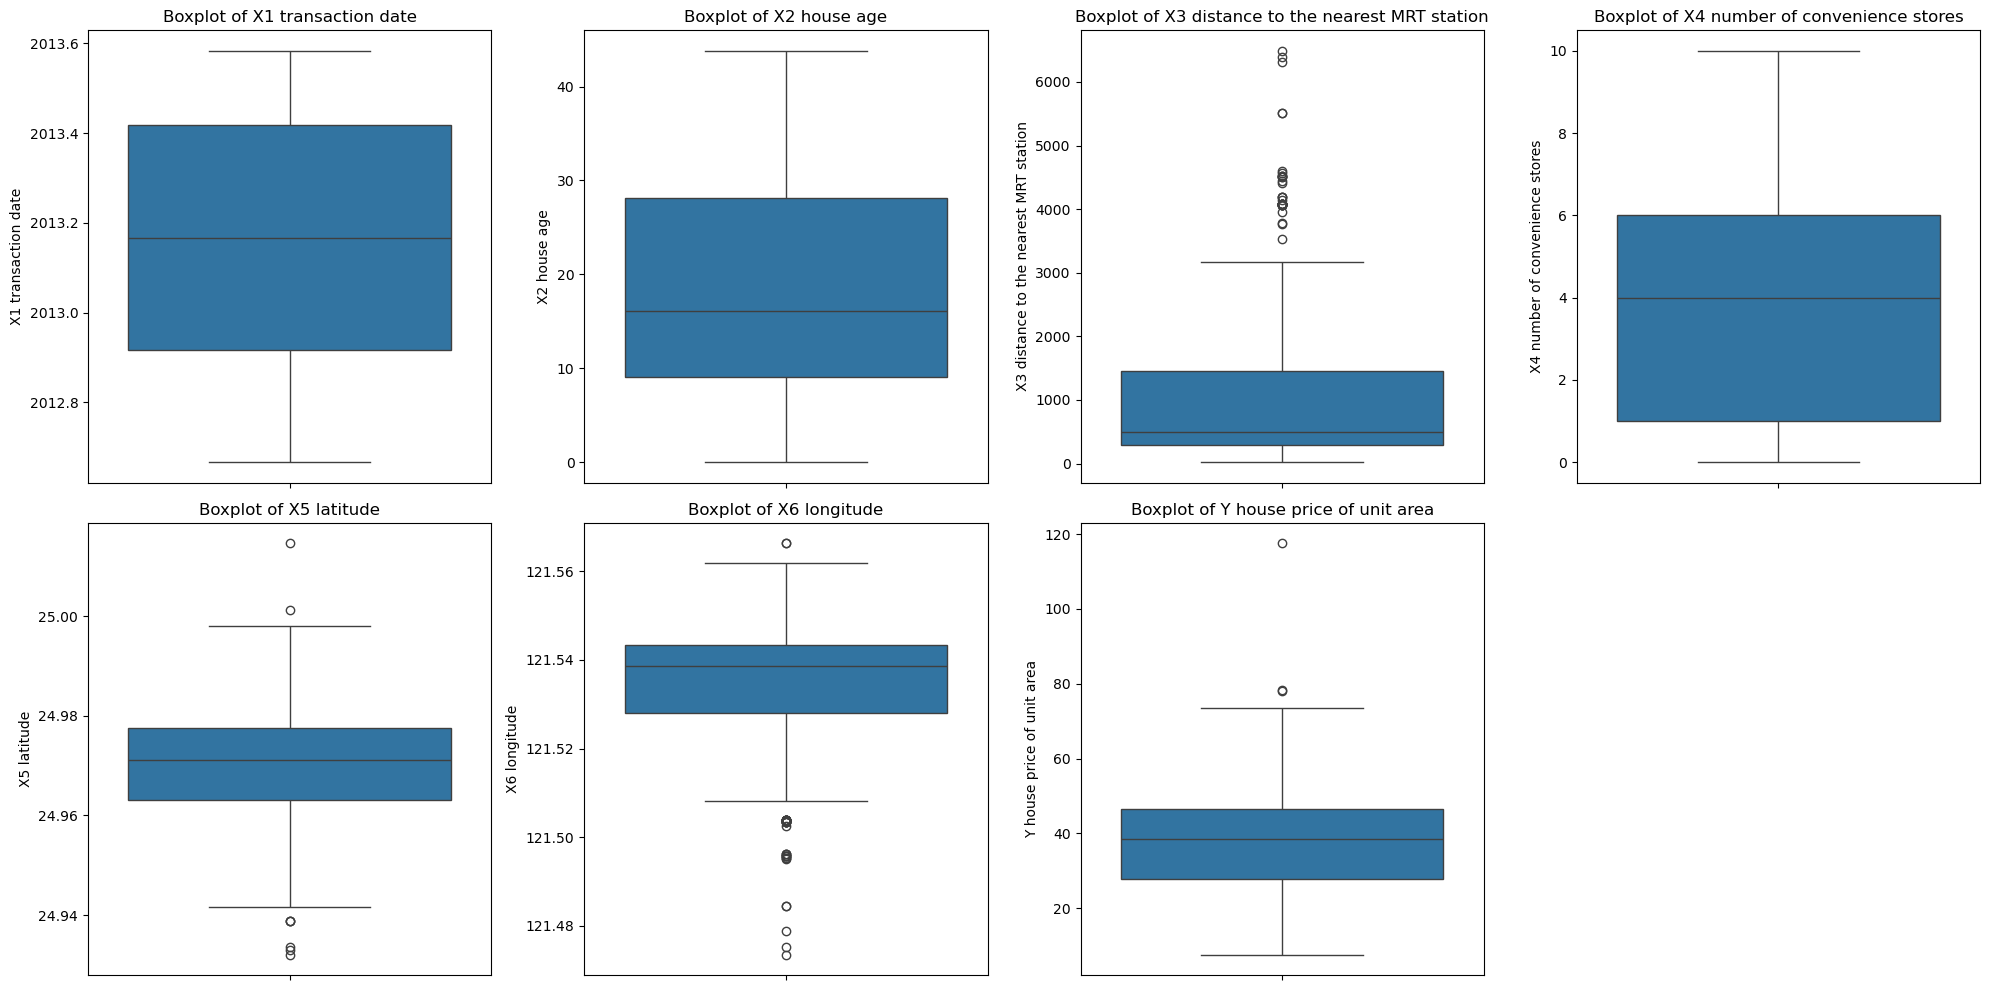

In [59]:
houses_fact_df =  matches.toPandas()
houses_fact_df.info()

# Create pairplot to identify outliers
plt.figure(figsize=(15, 12))
sns.pairplot(houses_fact_df[['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 
              'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 
              'Y house price of unit area']])
plt.suptitle('Pairplot to Identify Outliers', y=1.02)
plt.show()

# Create boxplots to better visualize outliers
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

columns = ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 
       'Y house price of unit area']

for i, col in enumerate(columns):
  sns.boxplot(data=houses_fact_df, y=col, ax=axes[i])
  axes[i].set_title(f'Boxplot of {col}')

# Remove the last empty subplot
axes[-1].remove()

plt.tight_layout()
plt.show()

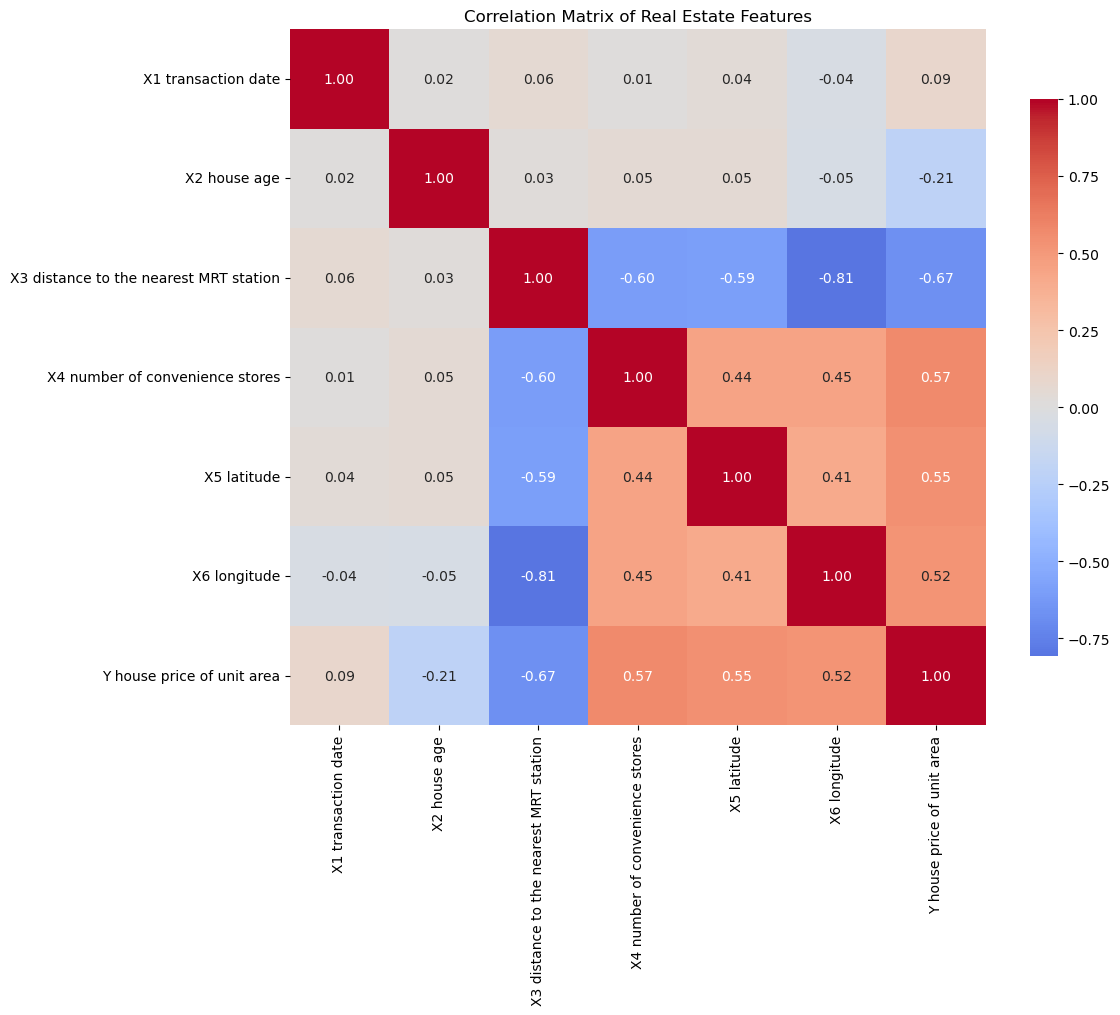

In [60]:
correlation_matrix = houses_fact_df[['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 
                   'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 
                   'Y house price of unit area']].corr()

# Visualize correlation matrix using heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
      square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Real Estate Features')
plt.tight_layout()
plt.show()

In [70]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import SparkSession
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml.regression import LinearRegression

houses_raw =  matches
houses_raw.printSchema()

# Select feature columns for scaling (excluding 'No' as it's just an index and target variable)
feature_cols = ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 
        'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']

# Create vector assembler for features
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
houses_assembled = assembler.transform(houses_raw)

# Apply MinMaxScaler
scaler = MinMaxScaler(inputCol="features_raw", outputCol="features_scaled")
scaler_model = scaler.fit(houses_assembled)
houses_scaled = scaler_model.transform(houses_assembled)

# Show the scaled features
houses_scaled.select("features_scaled", "Y house price of unit area").show(5, truncate=False)

train_data, test_data = houses_scaled.randomSplit([0.8, 0.2], seed=42)

print(f"Training set size: {train_data.count()}")
print(f"Test set size: {test_data.count()}")

root
 |-- No: integer (nullable = true)
 |-- X1 transaction date: double (nullable = true)
 |-- X2 house age: double (nullable = true)
 |-- X3 distance to the nearest MRT station: double (nullable = true)
 |-- X4 number of convenience stores: integer (nullable = true)
 |-- X5 latitude: double (nullable = true)
 |-- X6 longitude: double (nullable = true)
 |-- Y house price of unit area: double (nullable = true)
 |-- txn_year: integer (nullable = true)
 |-- txn_month: integer (nullable = true)

+--------------------------------------------------------------------------------------------------------+--------------------------+
|features_scaled                                                                                         |Y house price of unit area|
+--------------------------------------------------------------------------------------------------------+--------------------------+
|[0.27292576419208986,0.7305936073059361,0.00951267162646579,1.0,0.616941347552139,0.719322838041794

In [73]:
regressor = LinearRegression(featuresCol="features_scaled", labelCol="Y house price of unit area")
# Fit the model on training data
lr_model = regressor.fit(train_data)

# Get coefficients and intercept
print("Coefficients:", lr_model.coefficients)
print("Intercept:", lr_model.intercept)

# Print feature names for better understanding
feature_names = [
  "X1 transaction date",
  "X2 house age", 
  "X3 distance to the nearest MRT station",
  "X4 number of convenience stores",
  "X5 latitude",
  "X6 longitude"
]

print("\nFeature Coefficients:")
for i, (feature, coeff) in enumerate(zip(feature_names, lr_model.coefficients)):
  print(f"{feature}: {coeff}")

Coefficients: [4.739077999460709,-12.07494866106783,-29.554501221535006,10.489742586772882,20.292943868701425,-1.2660495403123755]
Intercept: 32.49365890177867

Feature Coefficients:
X1 transaction date: 4.739077999460709
X2 house age: -12.07494866106783
X3 distance to the nearest MRT station: -29.554501221535006
X4 number of convenience stores: 10.489742586772882
X5 latitude: 20.292943868701425
X6 longitude: -1.2660495403123755


In [77]:
predictions = lr_model.transform(test_data)
predictions.printSchema()
predictions.show(5,False)

root
 |-- No: integer (nullable = true)
 |-- X1 transaction date: double (nullable = true)
 |-- X2 house age: double (nullable = true)
 |-- X3 distance to the nearest MRT station: double (nullable = true)
 |-- X4 number of convenience stores: integer (nullable = true)
 |-- X5 latitude: double (nullable = true)
 |-- X6 longitude: double (nullable = true)
 |-- Y house price of unit area: double (nullable = true)
 |-- txn_year: integer (nullable = true)
 |-- txn_month: integer (nullable = true)
 |-- features_raw: vector (nullable = true)
 |-- features_scaled: vector (nullable = true)
 |-- prediction: double (nullable = false)

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+--------+---------+-----------------------------------------------+-----------------------------------------------------------------------------------------------------+------------------+
|No |X1 transactio

In [78]:
# YOUR CODE HERE
rmse = lr_model.summary.rootMeanSquaredError
print(f"Root Mean Squared Error (RMSE): {rmse}")
r_sqr = lr_model.summary.r2
print(f"R^2 (Coefficient of Determination): {r_sqr}")

Root Mean Squared Error (RMSE): 8.846209128611525
R^2 (Coefficient of Determination): 0.564301091360526
